# Part 4: Temporal Data

---
## Mô tả Dataset: Stock Market Data

### 1. Nguồn dữ liệu
- **Dataset**: Stock Market Data (NASDAQ, NYSE, S&P500)
- **Link Kaggle**: https://www.kaggle.com/datasets/paultimothymooney/stock-market-data

### 2. Cấu trúc thư mục
```
temporal/stock_market_data/
├── forbes2000/    (2246 files, 1076 files .csv)
├── nasdaq/        (3617 files, 1564 files .csv)
├── nyse/          (2516 files, 1145 files .csv)
└── sp500/         (831 files)
    ├── csv/       (409 file CSV)
    └── json/      (422 file JSON)
```
**Tổng cộng**: 4194 files .csv (mỗi file tương ứng với 1 mã cổ phiếu)

### 3. Cấu trúc file .csv
Mỗi file .csv chứa dữ liệu lịch sử của một mã cổ phiếu với các cột:

| Cột | Kiểu dữ liệu | Mô tả |
|-----|--------------|-------|
| **Date** | String (DD-MM-YYYY) | Ngày giao dịch |
| **Open** | Float | Giá mở cửa |
| **High** | Float | Giá cao nhất trong ngày |
| **Low** | Float | Giá thấp nhất trong ngày |
| **Close** | Float | Giá đóng cửa |
| **Volume** | Integer | Khối lượng giao dịch |
| **Adjusted Close** | Float | Giá đóng cửa đã điều chỉnh |

### 4. Lý do chọn mã cổ phiếu Apple (AAPL)  

Do dữ liệu quá nhiều với mỗi file .csv là thông tin 1 mã cỗ phiếu trong
giai đoạn 1980-2020 (có khoảng 4194 files .csv). Sau quá trình khảo sát và được
sự chấp nhận của thầy, nhóm quyết định chỉ chọn một mã cổ phiếu trên một sàn
giao dịch (tương ứng với 1 file .csv) để xử lý.   

Nhóm quyết định chọn mã cổ phiếu **Apple Inc. (AAPL)**. Vì:

1. AAPL có lịch sử giao dịch từ năm 1980 đến nay (khoảng 44 năm), thỏa yêu cầu về dữ liệu của thầy.

2. Apple là một trong những cổ phiếu được giao dịch nhiều nhất trên thị trường. Vì vậy chúng em kì vọng sẽ khai thác được nhiều thông tin thú vị.

3. AAPL là thành phần của cả 3 sàn (nhưng nhóm chỉ chọn khảo sát ở sàn S&P 500):
   - S&P 500
   - NASDAQ Composite
   - Dow Jones Industrial Average

5. Kích thước file: 10,590 lines và dữ liệu có time gaps (để làm phần Handling time gaps) phù hợp để áp dụng các kỹ thuật xử lý thầy yêu cầu.


## Import Thư viện

In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#for autocorrelation
from pandas.plotting import autocorrelation_plot

import warnings
warnings.filterwarnings('ignore')

#cho đẹp
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## Load Data
Cho phần xử lý này, em sẽ sử dụng dữ liệu cổ phiếu Apple (AAPL) từ S&P 500 (đã giải thích ở trên).

In [466]:
df = pd.read_csv('../data/temporal/stock_market_data/sp500/csv/AAPL.csv')

### Thông tin tổng quan dữ liệu

In [467]:
print(f"Số dòng: {len(df)}")
print(f"Số cột: {len(df.columns)}")
print(f"\nCác cột: {df.columns.tolist()}")
df.head(10)

Số dòng: 10590
Số cột: 7

Các cột: ['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492
5,19-12-1980,0.126116,0.126116,48630400,0.126674,0.126116,0.098137
6,22-12-1980,0.132254,0.132254,37363200,0.132813,0.132254,0.102913
7,23-12-1980,0.137835,0.137835,46950400,0.138393,0.137835,0.107256
8,24-12-1980,0.145089,0.145089,48003200,0.145647,0.145089,0.112901
9,26-12-1980,0.158482,0.158482,55574400,0.159040,0.158482,0.123322


### Thông tin các thuộc tính

In [468]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


**Đầu tiên, chúng ta sẽ tiến hành kiểm tra dữ liệu và kiểu dữ liệu hiện tại của biến thời gian.**

In [469]:
print("Kiểu dữ liệu cột Date:", df['Date'].dtype)
print("\nMẫu dữ liệu Date:")
print(df['Date'].head(10))

Kiểu dữ liệu cột Date: object

Mẫu dữ liệu Date:
0    12-12-1980
1    15-12-1980
2    16-12-1980
3    17-12-1980
4    18-12-1980
5    19-12-1980
6    22-12-1980
7    23-12-1980
8    24-12-1980
9    26-12-1980
Name: Date, dtype: object


Dữ liệu đang ở kiểu *object* với cấu trúc DD-MM-YYYY.  
**Bây giờ ta sẽ tiến hành parse dữ liệu này thành datetime object.**

In [470]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print("Kiểu dữ liệu sau khi parse:", df['Date'].dtype)
print("\nMẫu dữ liệu:")
df.head()

Kiểu dữ liệu sau khi parse: datetime64[ns]

Mẫu dữ liệu:


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


Xử lý xong kiểu dữ liệu rồi ta sẽ dựng trục thời gian cho dữ liệu (dùng pandas datetime index cho Date).  
**Đặt cột Date làm index để xử lý dữ liệu chuỗi thời gian.**

In [471]:
df_caua = df.set_index('Date')

**Sắp xếp lại theo thời gian (phòng trường hợp dữ liệu chưa được sắp xếp)**

In [472]:
df_caua = df_caua.sort_index()

**Kiểm tra phạm vi thời gian của dữ liệu**

In [473]:
start_date = df_caua.index.min()
end_date = df_caua.index.max()

print("Phạm vi thời gian của dữ liệu:")
print("Từ:", start_date)
print("Đến:", end_date)

Phạm vi thời gian của dữ liệu:
Từ: 1980-12-12 00:00:00
Đến: 2022-12-12 00:00:00


**Tính tổng số ngày trong khoảng thời gian này**

In [474]:
total_days = (end_date - start_date).days
print("Tổng thời gian:", total_days, "ngày")

df_caua.head()

Tổng thời gian: 15340 ngày


,Low,Open,Volume,High,Close,Adjusted Close
Date,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


**Để có thể quan sát xu hướng dữ liệu time series sau khi format về Datetime object, em sẽ dùng line chart cho giá chốt (Close price) để visualize.**

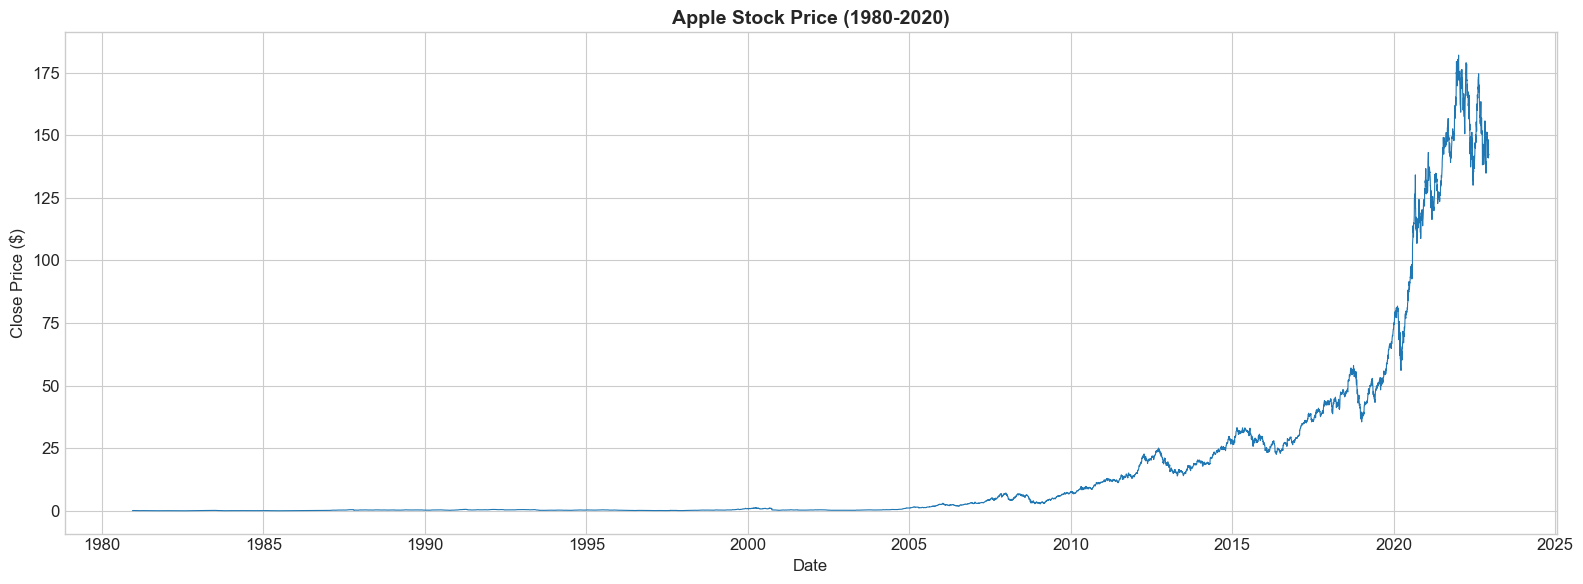

In [475]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_caua.index, df_caua['Close'], linewidth=0.8)
ax.set_title('Apple Stock Price (1980-2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

---
## b) Handling Time Gaps

#### **Yêu cầu bài làm**
-  Identify missing timestamps.
- Apply forward fill or backward fill methods.
- Use interpolation techniques (linear, polynomial, spline) and compare their effectiveness.

**Reset lại index trước khi fill**  
Em sẽ tạo 1 df mới dựa trên `df_caua` để tính toán time gaps.  

In [476]:
df_gap = df_caua.reset_index() 

**Tính khoảng cách thời gian giữa các ngày liên tiếp**

In [477]:
df_gap['TimeDiff'] = df_gap['Date'].diff()

df_gap.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close,TimeDiff
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874,NaT
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663,3 days
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715,1 days
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886,1 days
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492,1 days


Do dữ liệu là ở cấp ngày (mỗi datapoint cách nhau 1 ngày), nên để tìm time gaps em sẽ tìm những datapoint cách nhau nhiều hơn 1 ngày

In [478]:
gaps = df_gap[df_gap['TimeDiff'] > pd.Timedelta(days=1)]
print(f"Số khoảng trống > 1 ngày: {len(gaps)}")
print(f"\nPhân bố khoảng trống:")
print(gaps['TimeDiff'].value_counts().head(10))

Số khoảng trống > 1 ngày: 2289

Phân bố khoảng trống:
TimeDiff
3 days    1927
4 days     262
2 days      97
5 days       2
7 days       1
Name: count, dtype: int64


Mình đã có số liệu về những time gaps đang có của mã cổ phiếu. Bây giờ em sẽ visualize nó lên để có cái nhìn trực quan hơn

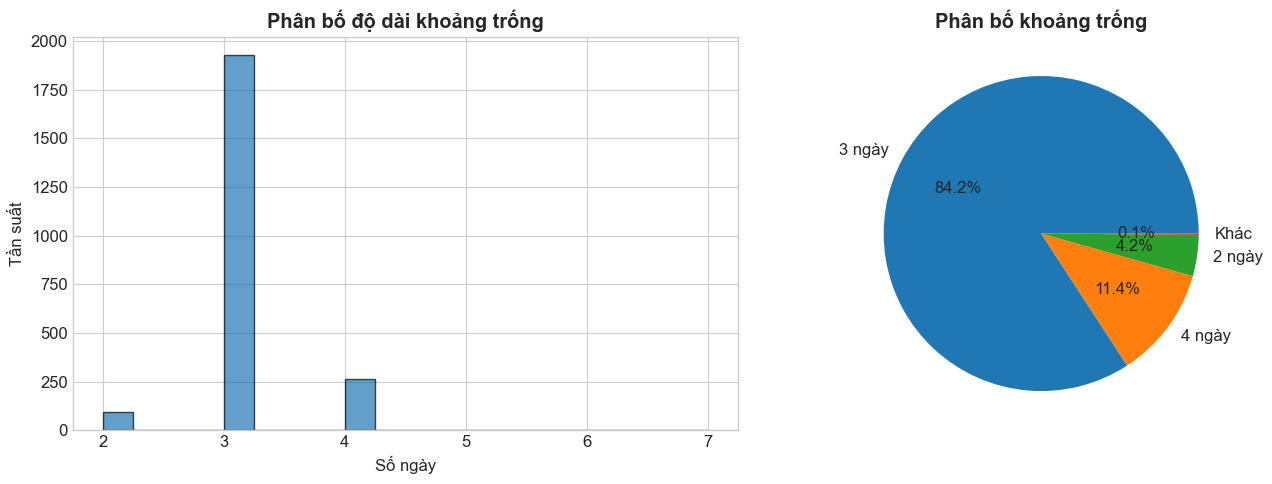

In [479]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gap_days = gaps['TimeDiff'].dt.days
axes[0].hist(gap_days, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân bố độ dài khoảng trống', fontweight='bold')
axes[0].set_xlabel('Số ngày')
axes[0].set_ylabel('Tần suất')

gap_counts = gap_days.value_counts().head(5)

total = gap_counts.sum()
small = gap_counts[gap_counts / total <= 0.02]
large = gap_counts[gap_counts / total > 0.02]

if len(small) > 0:
    large["Khác"] = small.sum()

axes[1].pie(
    large.values,
    labels=[f'{d} ngày' if isinstance(d, int) else d for d in large.index],
    autopct='%1.1f%%'
)
axes[1].set_title('Phân bố khoảng trống', fontweight='bold')


plt.tight_layout()
plt.show()

**Em sẽ tạo chuỗi thời gian thực và đối chiếu với dữ liệu xem chúng ta bị thiếu bao nhiêu ngày**

Do tìm hiểu được stock data không có data ngày nghỉ và ngày lễ nên ngày nghỉ và ngày lễ không có data chứ không phải missing data.

Tuy nhiên, đối với nhiều kỹ thuật xử lý time-series, việc dữ liệu không liên tục có thể gây ảnh hưởng (vd: trong bài làm này nếu không liên tục sẽ khó tạo lag features, differences features, rolling statictis). Nên em sẽ fill cho toàn bộ ngày.

In [480]:
start_date = df_caua.index.min()
end_date = df_caua.index.max()

date_range = pd.date_range(start=start_date, end=end_date, freq='D')

**Reindex lại DataFrame để bổ sung các ngày còn thiếu**

In [481]:
df_caub = df_caua.reindex(date_range)

**So sánh số lượng dòng trước và sau khi reindex**

In [482]:
print("Số dòng ban đầu:", len(df_caua))
print("Số dòng sau khi reindex:", len(df_caub))

Số dòng ban đầu: 10590
Số dòng sau khi reindex: 15341


**Đếm số ngày bị thiếu dữ liệu (giá trị Close bị NaN)**

In [483]:
missing_days = df_caub[df_caub.isna().all(axis=1)].copy()
print("Số ngày thiếu dữ liệu:", missing_days.shape[0])

Số ngày thiếu dữ liệu: 4751


**Kiểm tra những ngày bị thiếu rơi vào ngày nào trong tuần (phục vụ cho report)**

Phân bố missing theo thứ trong tuần:
Weekday
Friday         77
Monday        188
Saturday     2192
Sunday       2192
Thursday       61
Tuesday        20
Wednesday      21
Name: count, dtype: int64


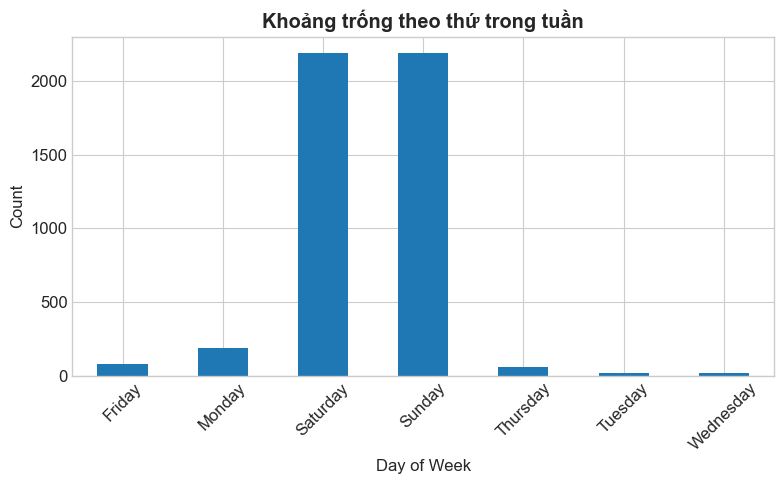

In [484]:
missing_days["Weekday"] = missing_days.index.day_name()

# Đếm số lượng theo từng thứ
missing_by_weekday = missing_days["Weekday"].value_counts().sort_index()

print("Phân bố missing theo thứ trong tuần:")
print(missing_by_weekday)

plt.figure(figsize=(8,5))
missing_by_weekday.plot(kind='bar')

plt.title("Khoảng trống theo thứ trong tuần", fontweight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### **Các kỹ thuật Handling Time Gaps sử dụng**

Dựa trên yêu cầu đề bài, có **5 kỹ thuật** cần được triển khai và so sánh, bao gồm:

##### **1. Fill Methods**
* Forward Fill
* Backward Fill

##### **2. Interpolation Methods**
* Linear Interpolation
* Polynomial Interpolation
* Spline Interpolation

Để so sánh và chọn ra kĩ thuật phù hợp, em sẽ áp dụng cho cột `Close` của Dữ liệu. Trong thực tế khi preprocessing toàn bộ dataset để sử dụng, nên fill tất cả các cột giá (Open, High, Low, Close) bằng cùng phương pháp, và xử lý Volume riêng (forward fill hoặc fill = 0).

In [485]:
# 1. Forward Fill
df_ffill = df_caub['Close'].ffill()

# 2. Backward Fill
df_bfill = df_caub['Close'].bfill()

# 3. Linear Interpolation
df_linear = df_caub['Close'].interpolate(method='linear')

# 4. Polynomial Interpolation (order=2)
df_poly = df_caub['Close'].interpolate(method='polynomial', order=2)

# 5. Spline Interpolation (order=3 - cubic spline)
df_spline = df_caub['Close'].interpolate(method='spline', order=3)

**Bây giờ em sẽ lấy 1 khoảng có gap để visualize lên so sánh 5 phương pháp handling time gaps này**

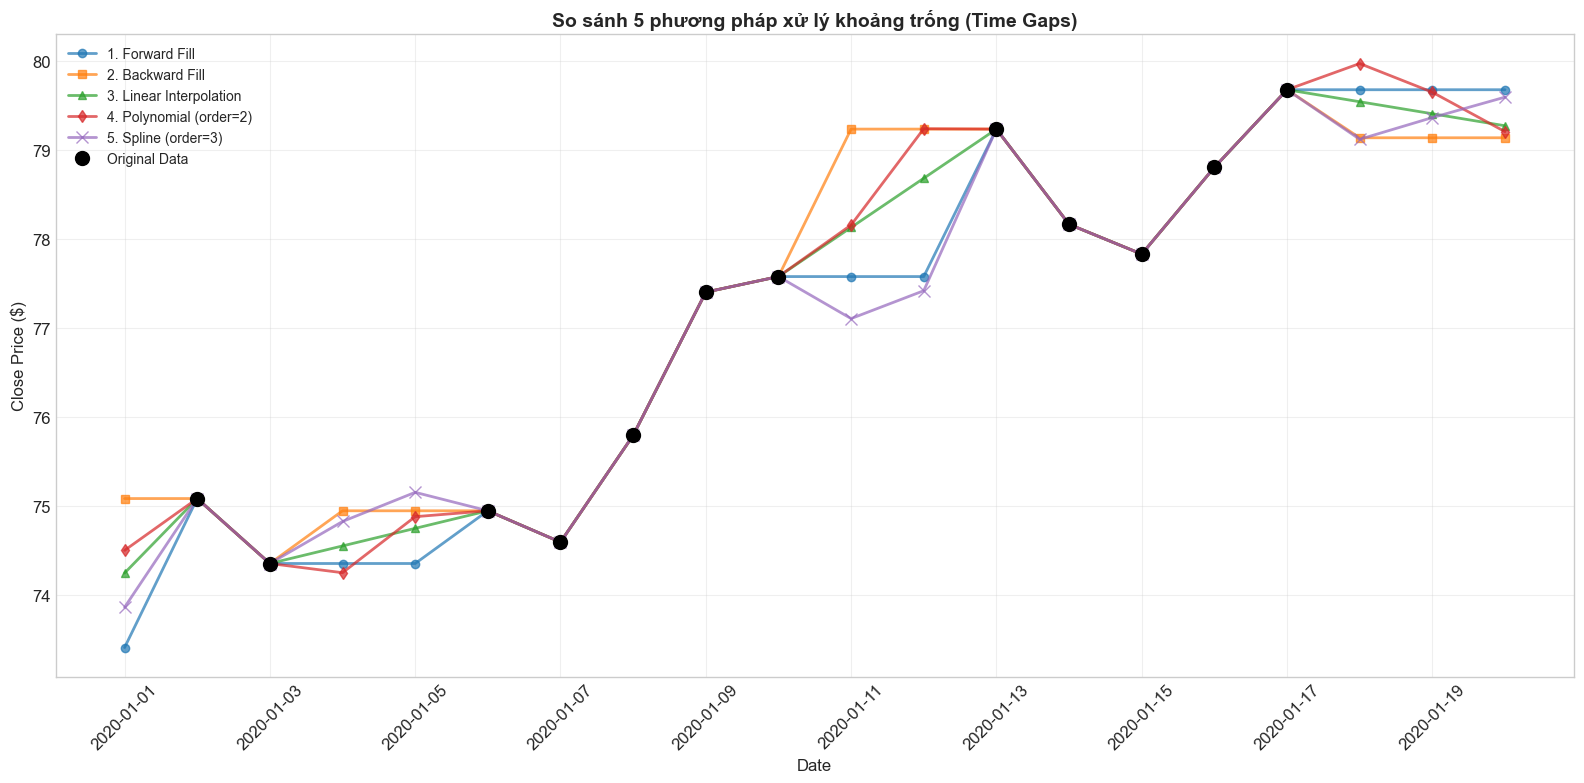

In [486]:
sample_start = '2020-01-01'
sample_end = '2020-01-20'

fig, ax = plt.subplots(figsize=(16, 8))

# Plot all 5 methods
ax.plot(df_ffill[sample_start:sample_end], 'o-', label='1. Forward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_bfill[sample_start:sample_end], 's-', label='2. Backward Fill', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_linear[sample_start:sample_end], '^-', label='3. Linear Interpolation', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_poly[sample_start:sample_end], 'd-', label='4. Polynomial (order=2)', alpha=0.7, markersize=6, linewidth=2)
ax.plot(df_spline[sample_start:sample_end], 'x-', label='5. Spline (order=3)', alpha=0.7, markersize=8, linewidth=2)

# Plot original data points
original = df_caub['Close'][sample_start:sample_end]
ax.plot(original.dropna(), 'ko', label='Original Data', markersize=10, zorder=5)

ax.set_title('So sánh 5 phương pháp xử lý khoảng trống (Time Gaps)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Forward Fill** và **Backward Fill** tạo nên hình các bậc thang do không tạo ra giá trị mới mà lấy giá trị trước/sau của điểm gap để fill vào.
- **Các phương pháp nội suy** tạo thành các đường nối mượt hơn giữa các điểm. Tuy nhiên, các đường này tạo nên những giá trị ảo (chỉ mô phỏng giá trị missing dựa trên xu hướng dữ liệu).

Vì vậy, em sẽ chọn 1 trong 2 loại fill cho Dataset này. Ở đây do dữ liệu là stock data nên em sẽ ưu tiên chọn ffill để giữ giá cũ trước khi có thay đổi mới.

#### **Áp dụng phương pháp được chọn cho toàn bộ dữ liệu**

Dựa trên phân tích ở trên, em quyết định chọn **Forward Fill**. Bây giờ em sẽ áp dụng phương pháp này để xử lý toàn bộ các cột trong dataset.

In [487]:
# Áp dụng Forward Fill cho tất cả các cột giá
price_columns = ['Open', 'High', 'Low', 'Close', 'Adjusted Close']
for col in price_columns:
    if col in df_caub.columns:
        df_caub[col] = df_caub[col].ffill()

# Xử lý Volume: forward fill (hoặc có thể fill = 0), ở đây em sẽ dùng ffill
if 'Volume' in df_caub.columns:
    df_caub['Volume'] = df_caub['Volume'].ffill()

print("Số lượng giá trị NaN còn lại sau khi fill:")
print(df_caub.isna().sum())
print(f"\nTổng số dòng: {len(df_caub)}")
print(f"Dòng hoàn chỉnh (không có NaN): {df_caub.notna().all(axis=1).sum()}")
df_caub.head(10)

Số lượng giá trị NaN còn lại sau khi fill:
Low               0
Open              0
Volume            0
High              0
Close             0
Adjusted Close    0
dtype: int64

Tổng số dòng: 15341
Dòng hoàn chỉnh (không có NaN): 15341


,Low,Open,Volume,High,Close,Adjusted Close
1980-12-12,0.128348,0.128348,469033600.0,0.128906,0.128348,0.099874
1980-12-13,0.128348,0.128348,469033600.0,0.128906,0.128348,0.099874
1980-12-14,0.128348,0.128348,469033600.0,0.128906,0.128348,0.099874
1980-12-15,0.121652,0.122210,175884800.0,0.122210,0.121652,0.094663
1980-12-16,0.112723,0.113281,105728000.0,0.113281,0.112723,0.087715
1980-12-17,0.115513,0.115513,86441600.0,0.116071,0.115513,0.089886
1980-12-18,0.118862,0.118862,73449600.0,0.119420,0.118862,0.092492
1980-12-19,0.126116,0.126116,48630400.0,0.126674,0.126116,0.098137
1980-12-20,0.126116,0.126116,48630400.0,0.126674,0.126116,0.098137
1980-12-21,0.126116,0.126116,48630400.0,0.126674,0.126116,0.098137


---
## c) Extracting Time-Based Features

#### **Yêu cầu bài làm**
- Extract cyclical features (day of week, month, season). 
- Create indicator variables for special periods (holidays, weekends).
- Encode cyclical features using sine/cosine transformations.
- Extract time elapsed since specific events.

**Load df để sẵn sàng cho bước extracting**

In [488]:
df_cauc = df_caub.copy()

**Extract time features từ DatetimeIndex để tiện hơn cho các bước extract feature**

In [489]:
df_cauc['Year'] = df_cauc.index.year
df_cauc['Month'] = df_cauc.index.month
df_cauc['Day'] = df_cauc.index.day
df_cauc['DayOfWeek'] = df_cauc.index.dayofweek  # 0=Monday, 6=Sunday
df_cauc['DayName'] = df_cauc.index.day_name()
df_cauc['Quarter'] = df_cauc.index.quarter
df_cauc['WeekOfYear'] = df_cauc.index.isocalendar().week

print("Các thành phần thời gian đã trích xuất từ index:")
df_cauc[['Year', 'Month', 'Day', 'DayOfWeek', 'DayName', 'Quarter', 'WeekOfYear']].head(10)

Các thành phần thời gian đã trích xuất từ index:


,Year,Month,Day,DayOfWeek,DayName,Quarter,WeekOfYear
1980-12-12,1980,12,12,4,Friday,4,50
1980-12-13,1980,12,13,5,Saturday,4,50
1980-12-14,1980,12,14,6,Sunday,4,50
1980-12-15,1980,12,15,0,Monday,4,51
1980-12-16,1980,12,16,1,Tuesday,4,51
1980-12-17,1980,12,17,2,Wednesday,4,51
1980-12-18,1980,12,18,3,Thursday,4,51
1980-12-19,1980,12,19,4,Friday,4,51
1980-12-20,1980,12,20,5,Saturday,4,51
1980-12-21,1980,12,21,6,Sunday,4,51


**Cyclical Encoding**

Với các feature có tính chu kỳ (tháng, ngày trong tuần), nếu mình encode thông thường (Month = 1, 2, 3..., 12) sẽ gặp vấn đề:
- Khi thực hiện bước modeling, model sẽ hiểu là (12 > 11 > ... > 1) như vậy thì không đúng bản chất dữ liệu có chu kì như dữ liệu thời gian.

**Giải pháp:**
- Ta cần tạo nên tính chu kì cho thời gian bằng sin, cos.

Nhóm em sẽ áp dụng cyclical encoding cho: **Month, DayOfWeek, DayOfYear**

In [490]:
df_cauc['Month_sin'] = np.sin(2 * np.pi * df_cauc['Month'] / 12)
df_cauc['Month_cos'] = np.cos(2 * np.pi * df_cauc['Month'] / 12)
df_cauc['DayOfWeek_sin'] = np.sin(2 * np.pi * df_cauc['DayOfWeek'] / 7)
df_cauc['DayOfWeek_cos'] = np.cos(2 * np.pi * df_cauc['DayOfWeek'] / 7)
df_cauc['DayOfYear'] = df_cauc.index.dayofyear
df_cauc['DayOfYear_sin'] = np.sin(2 * np.pi * df_cauc['DayOfYear'] / 365)
df_cauc['DayOfYear_cos'] = np.cos(2 * np.pi * df_cauc['DayOfYear'] / 365)

print("Cyclical features:")
df_cauc[['Month', 'Month_sin', 'Month_cos', 'DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos']].head(10)

Cyclical features:


,Month,Month_sin,Month_cos,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
1980-12-12,12,-2.449294e-16,1.0,4,-0.433884,-0.900969
1980-12-13,12,-2.449294e-16,1.0,5,-0.974928,-0.222521
1980-12-14,12,-2.449294e-16,1.0,6,-0.781831,0.623490
1980-12-15,12,-2.449294e-16,1.0,0,0.000000,1.000000
1980-12-16,12,-2.449294e-16,1.0,1,0.781831,0.623490
1980-12-17,12,-2.449294e-16,1.0,2,0.974928,-0.222521
1980-12-18,12,-2.449294e-16,1.0,3,0.433884,-0.900969
1980-12-19,12,-2.449294e-16,1.0,4,-0.433884,-0.900969
1980-12-20,12,-2.449294e-16,1.0,5,-0.974928,-0.222521
1980-12-21,12,-2.449294e-16,1.0,6,-0.781831,0.623490


**Binary encoding features**

Ngoài cyclical encoding, em sẽ tạo thêm các biến indicator (0/1) để đánh dấu những ngày đặc biệt.

- Cuối quý/cuối năm có thể có volume giao dịch cao do portfolio rebalancing

**Binary Indicators**
- Monday thường có xu hướng giá khác so với các ngày khác (Monday effect), tương tự với Monday effect, em sẽ khảo sát thêm Friday effect.
- Giúp model dễ dàng học các pattern đặc biệt (ví dụ: hiệu ứng đầu tuần, cuối tháng).

Đề có yêu cầu weekend và holiday data, tuy nhiên do đã trình bày ở phần b. Handling Time Gaps, dữ liệu stock chỉ có trong ngày hành chính nên em xin phép không khai thác những feature liên quan đến holidays.

**Tạo biến cho ngày trong tuần**

In [491]:
df_cauc['IsMonday'] = (df_cauc['DayOfWeek'] == 0)
df_cauc['IsFriday'] = (df_cauc['DayOfWeek'] == 4)

df_cauc['IsMonday'] = df_cauc['IsMonday'].astype(int)
df_cauc['IsFriday'] = df_cauc['IsFriday'].astype(int)

**Tạo biến đầu tháng, cuối tháng, cuối quý, cuối năm (dựa trên Calendar Effects)**

Do không có kiến thức nền liên quan đến stock data để khai thác sâu hơn các effect dạng month of the year, turn of the year,... Nên em sẽ chọn khai thác những đặc trưng mang tính general hơn nhưng vẫn thể hiện được thông tin có ích của dữ liệu  

Đề có yêu cầu holiday data, tuy nhiên do đã trình bày ở phần b. Handling Time Gaps, dữ liệu stock chỉ có trong ngày hành chính nên em xin phép không khai thác những feature liên quan đến holidays.

In [492]:
df_cauc['IsMonthStart'] = df_cauc.index.is_month_start.astype(int)
df_cauc['IsQuarterEnd'] = df_cauc.index.is_quarter_end.astype(int)
df_cauc['IsYearEnd'] = df_cauc.index.is_year_end.astype(int)

**Time elapsed since specific events**

Em sẽ khảo sát khoảng cách của ngày trong tháng cho biến này

In [493]:
df_cauc['DaysSinceMonthStart'] = (
    df_cauc.index - df_cauc.index.to_period('M').to_timestamp()
).days

**Tạo cột Season**

In [494]:
def get_season(month):
    if month == 12 or month == 1 or month == 2:
        return 'Winter'
    elif month == 3 or month == 4 or month == 5:
        return 'Spring'
    elif month == 6 or month == 7 or month == 8:
        return 'Summer'
    else:
        return 'Fall'

In [495]:
df_cauc['Season'] = df_cauc['Month'].apply(get_season)

print("Kiểm tra lại kết quả extract:")
df_cauc[['IsMonday', 'IsFriday',
         'IsQuarterEnd', 'Season']].head(10)


Kiểm tra lại kết quả extract:


,IsMonday,IsFriday,IsQuarterEnd,Season
1980-12-12,0,1,0,Winter
1980-12-13,0,0,0,Winter
1980-12-14,0,0,0,Winter
1980-12-15,1,0,0,Winter
1980-12-16,0,0,0,Winter
1980-12-17,0,0,0,Winter
1980-12-18,0,0,0,Winter
1980-12-19,0,1,0,Winter
1980-12-20,0,0,0,Winter
1980-12-21,0,0,0,Winter


**Kiểm tra các cyclical features đã extract**

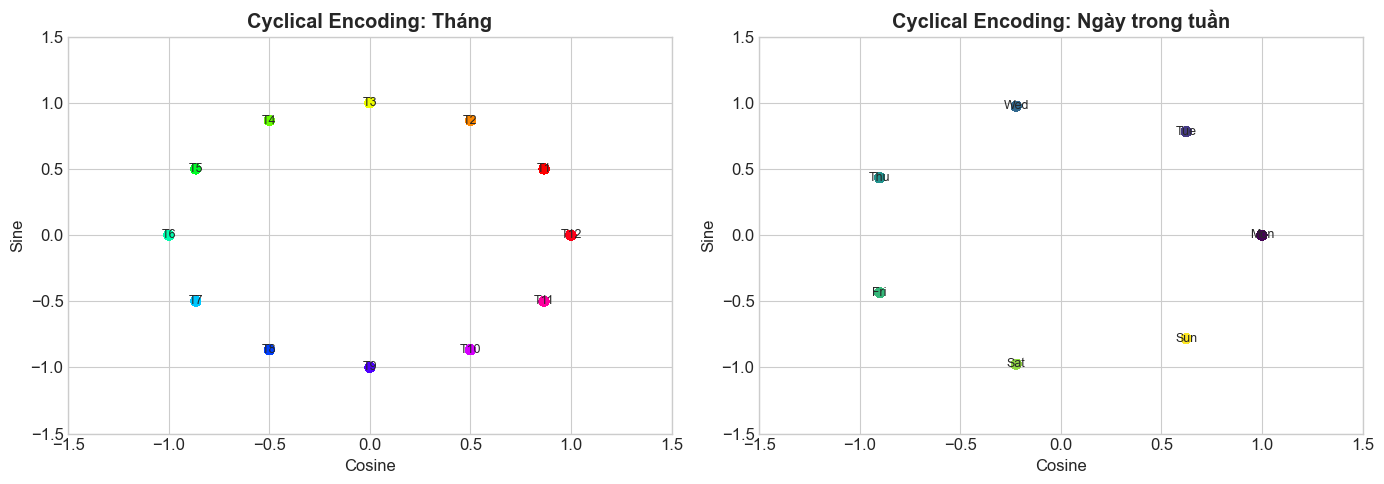

In [496]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ====== MONTH ======
axes[0].scatter(
    df_cauc['Month_cos'],
    df_cauc['Month_sin'],
    c=df_cauc['Month'],
    cmap='hsv',
    s=40,
    alpha=0.6
)

# annotate mỗi tháng duy nhất (tránh lặp)
unique_months = df_cauc[['Month', 'Month_sin', 'Month_cos']].drop_duplicates().sort_values('Month')

for _, row in unique_months.iterrows():
    axes[0].annotate(
        f"T{int(row['Month'])}",
        (row['Month_cos'], row['Month_sin']),
        fontsize=9,
        ha='center',
        va='center'
    )

axes[0].set_xlabel('Cosine')
axes[0].set_ylabel('Sine')
axes[0].set_title('Cyclical Encoding: Tháng', fontweight='bold')
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)


# ====== DAY OF WEEK ======
axes[1].scatter(
    df_cauc['DayOfWeek_cos'],
    df_cauc['DayOfWeek_sin'],
    c=df_cauc['DayOfWeek'],
    cmap='viridis',
    s=40,
    alpha=0.6
)

unique_days = df_cauc[['DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos']].drop_duplicates().sort_values('DayOfWeek')

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for _, row in unique_days.iterrows():
    axes[1].annotate(
        day_names[int(row['DayOfWeek'])],
        (row['DayOfWeek_cos'], row['DayOfWeek_sin']),
        fontsize=9,
        ha='center',
        va='center'
    )

axes[1].set_xlabel('Cosine')
axes[1].set_ylabel('Sine')
axes[1].set_title('Cyclical Encoding: Ngày trong tuần', fontweight='bold')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

**Kiểm tra các biến binary và season vừa tạo**

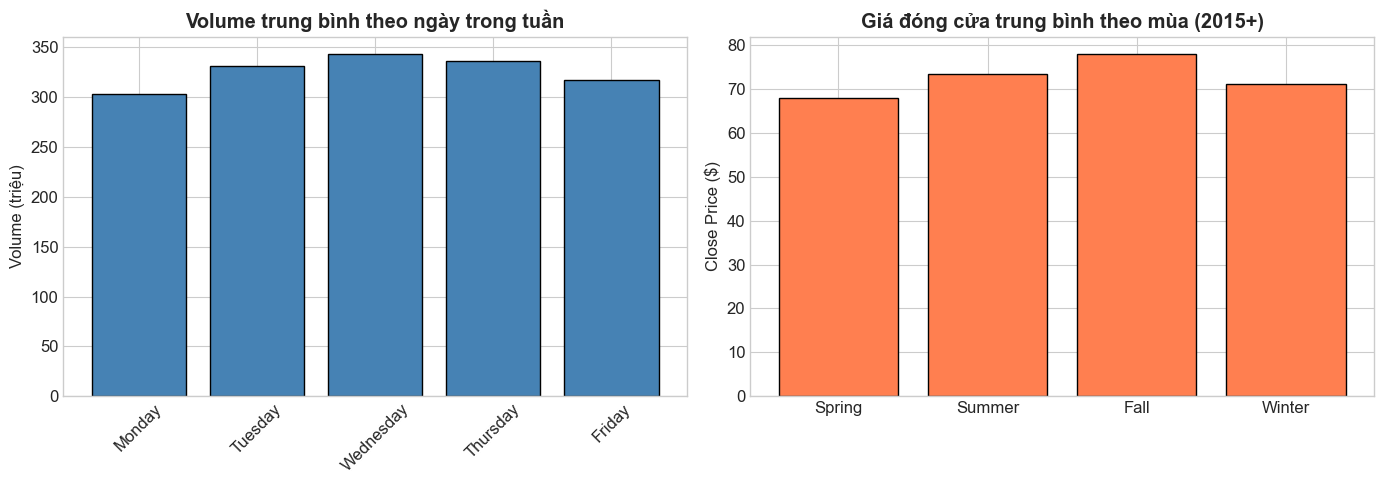

In [497]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#vol
vol_by_day = df_cauc.groupby('DayName')['Volume'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
axes[0].bar(vol_by_day.index, vol_by_day.values / 1e6, color='steelblue', edgecolor='black')
axes[0].set_title('Volume trung bình theo ngày trong tuần', fontweight='bold')
axes[0].set_ylabel('Volume (triệu)')
axes[0].tick_params(axis='x', rotation=45)

#close
recent_data = df_cauc[df_cauc['Year'] >= 2015]
close_by_season = recent_data.groupby('Season')['Close'].mean().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
axes[1].bar(close_by_season.index, close_by_season.values, color='coral', edgecolor='black')
axes[1].set_title('Giá đóng cửa trung bình theo mùa (2015+)', fontweight='bold')
axes[1].set_ylabel('Close Price ($)')

plt.tight_layout()
plt.show()

Để khảo sát hiệu quả của các feature vừa extract, em sẽ chọn cách đơn giản nhất đó là khảo sát độ tương quan của các features với 1 biến giá

In [498]:
corr_matrix = df_cauc[['Close', 'Month', 'Month_sin', 'Month_cos', 
                       'DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos',
                       'IsMonday', 'IsFriday',
                       'IsMonthStart', 'IsQuarterEnd', 'IsYearEnd',
                       'DaysSinceMonthStart']].corr()

print(corr_matrix['Close'].sort_values(ascending=False))

Close                  1.000000
Month                  0.024596
Month_cos              0.006151
IsMonthStart           0.000381
DayOfWeek_sin          0.000290
IsMonday               0.000289
DayOfWeek_cos          0.000116
IsFriday              -0.000173
DayOfWeek             -0.000354
DaysSinceMonthStart   -0.001333
IsQuarterEnd          -0.001373
IsYearEnd             -0.001472
Month_sin             -0.027759
Name: Close, dtype: float64


---
## d) Resampling Time Series Data

#### **Yêu cầu đề bài**
-  Choose suitable techniques such as upsampling (interpolation), downsampling (aggregation), or different aggregation functions (mean, sum, max, min). 
- Then, compare the effects of different resampling frequencies on data characteristics.

#### **Phương hướng tiếp cận**
- Em sẽ tìm hiểu cả upsampling và downsampling, tìm ra lựa chọn phù hợp cho bộ dữ liệu cũng như cho những loại dữ liệu Temporal có cùng tính chất. Và chỉ áp dụng phương pháp pù hợp cho bộ dữ liệu.

#### 1. Upsampling và Downsampling

**Upsampling** 
* Là việc chuyển dữ liệu sang tần suất cao hơn (ví dụ: từ monthly → daily, hoặc daily → hourly). 
* Nhưng ở đây do dữ liệu chỉ có ngày nên nếu muốn có dữ liệu hourly trở xuống ta cần dùng các phương pháp fill, nội suy. 

**Downsampling** 
* Là việc chuyển dữ liệu sang tần suất thấp hơn (ví dụ: từ daily → weekly hoặc monthly). 
* Khi thực hiện downsampling, ta cần chọn hàm tổng hợp phù hợp như mean, sum, max, min hoặc last value tùy theo bản chất của từng biến. Cách này giúp làm mượt dữ liệu, giảm nhiễu ngắn hạn và có thể làm thay đổi đặc tính thống kê của chuỗi.


Vì dataset là dữ liệu giá cổ phiếu theo ngày, việc upsampling có thể không phù hợp do không bổ sung thêm thông tin thực tế mà chỉ tạo ra dữ liệu nội suy. Do đó, trọng tâm phân tích sẽ là downsampling sang các tần suất thấp hơn như weekly và monthly.

#### 2. Triển khai Downsampling

**Gộp dữ liệu theo tuần**

In [499]:
df_weekly = df_cauc.resample('W')

**Lấy giá mở cửa đầu tuần**

In [500]:
weekly_open = df_weekly['Open'].first()

**Giá cao nhất và thấp nhất trong tuần**

In [501]:
weekly_high = df_weekly['High'].max()
weekly_low = df_weekly['Low'].min()

**Giá đóng cửa cuối tuần**

In [502]:
weekly_close = df_weekly['Close'].last()

**Tổng khối lượng giao dịch trong tuần**

In [503]:
weekly_volume = df_weekly['Volume'].sum()

**Gộp các kết quả lại thành DataFrame**

In [504]:
df_weekly = pd.concat(
    [weekly_open, weekly_high, weekly_low, weekly_close, weekly_volume],
    axis=1
)

print("Kích thước dữ liệu theo tuần:", df_weekly.shape)
df_weekly.head()

Kích thước dữ liệu theo tuần: (2193, 5)


,Open,High,Low,Close,Volume
1980-12-14,0.128348,0.128906,0.128348,0.128348,1.407101e+09
1980-12-21,0.122210,0.126674,0.112723,0.126116,5.873952e+08
1980-12-28,0.132254,0.159040,0.132254,0.158482,3.470432e+08
1981-01-04,0.160714,0.161272,0.152344,0.154018,2.985248e+08
1981-01-11,0.151228,0.151228,0.135045,0.142299,2.409120e+08


**So sánh các tần suất resampling**
###### Lấy dữ liệu giá đóng cửa trong giai đoạn 2019–2020

In [505]:
recent = df_cauc['Close']['2019':'2020']
weekly = recent.resample('W').mean()
monthly = recent.resample('ME').mean()

**So sánh các tần suất Resampling (2019-2020)**

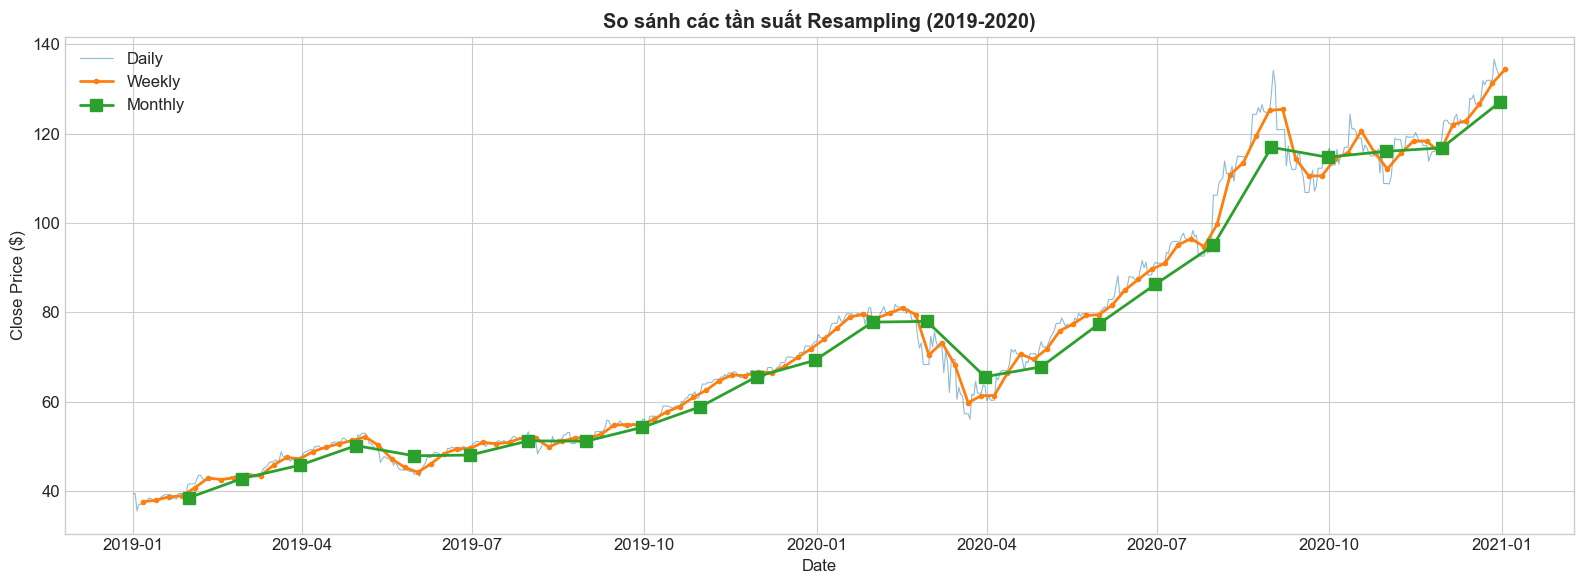

In [506]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent.index, recent.values, alpha=0.5, label='Daily', linewidth=0.8)
ax.plot(weekly.index, weekly.values, 'o-', label='Weekly', linewidth=2, markersize=3)
ax.plot(monthly.index, monthly.values, 's-', label='Monthly', linewidth=2, markersize=8)

ax.set_title('So sánh các tần suất Resampling (2019-2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**So sánh các aggregation functions**

###### Lấy dữ liệu giá đóng cửa trong năm 2020

In [507]:
close_2020 = df_cauc.loc['2020', 'Close']
monthly_close = close_2020.resample('M')

df_agg = pd.DataFrame()
df_agg['mean'] = monthly_close.mean()
df_agg['min'] = monthly_close.min()
df_agg['max'] = monthly_close.max()
df_agg['sum'] = monthly_close.sum()
df_agg['median'] = monthly_close.median()
df_agg['std'] = monthly_close.std()

print("Bảng so sánh các Aggregation Functions (Monthly resampling - 2020):")
df_agg

Bảng so sánh các Aggregation Functions (Monthly resampling - 2020):


,mean,min,max,sum,median,std
2020-01-31,77.840484,73.412498,81.084999,2413.055000,78.169998,2.191683
2020-02-29,77.995948,68.339996,81.800003,2261.882484,79.902496,4.120110
2020-03-31,65.605565,56.092499,75.684998,2033.772507,63.702499,5.702016
2020-04-30,67.820333,60.227501,73.449997,2034.609978,68.891251,3.912555
2020-05-31,77.468388,72.267502,79.807503,2401.520027,77.852501,2.405979
2020-06-30,86.291999,80.462502,91.632500,2588.759979,87.430000,3.359711
2020-07-31,95.008548,91.027496,106.260002,2945.264977,95.477501,3.059198
2020-08-31,116.974517,106.260002,129.039993,3626.210022,114.907501,6.872645
2020-09-30,114.758332,106.839996,134.179993,3442.749954,112.549999,6.558523
2020-10-31,116.066129,108.860001,124.400002,3598.050003,115.980003,3.395171


**Khảo sát các hàm aggregation vừa tạo**

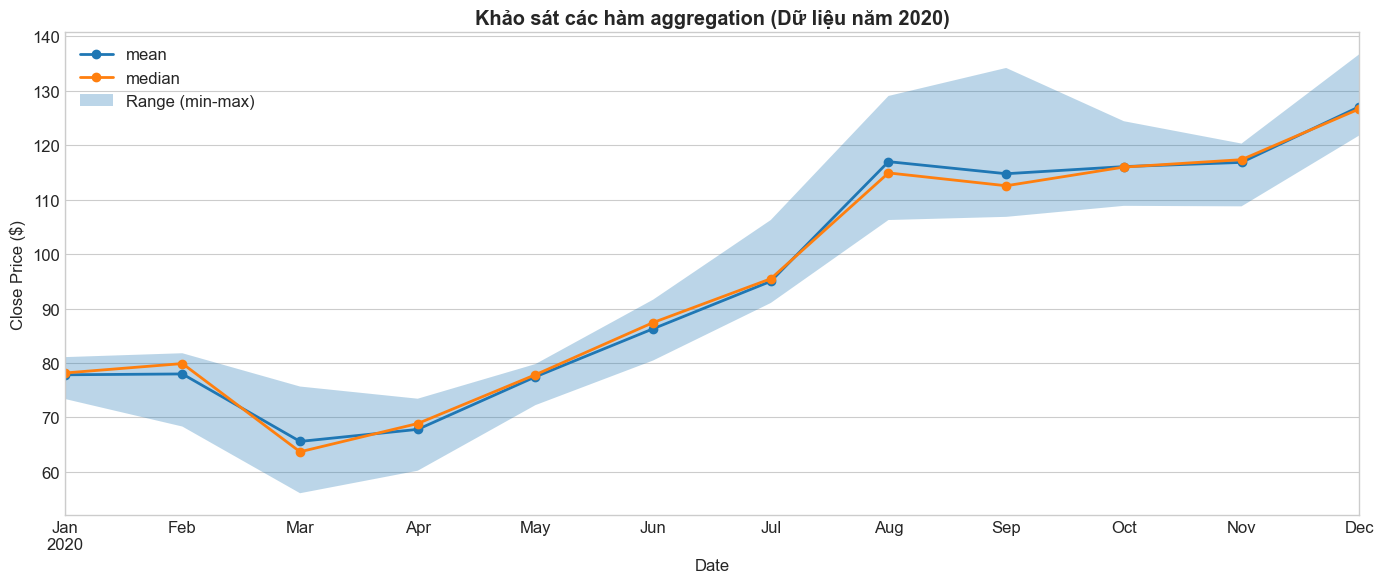

In [508]:
fig, ax = plt.subplots(figsize=(14, 6))
df_agg[['mean', 'median']].plot(ax=ax, marker='o', linewidth=2)
ax.fill_between(df_agg.index, df_agg['min'], df_agg['max'], alpha=0.3, label='Range (min-max)')

ax.set_title('Khảo sát các hàm aggregation (Dữ liệu năm 2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Đường mean (xanh dương) và median (vàng) khá khớp nhau trong cả năm.
- Range giữa min với max cho thấy một số sự biến động trong 1 năm: giãn rộng nhất vào tháng 8, tháng 9 và hẹp nhất ở tháng 5, tháng 6.
- Dựa vào các hàm aggregation ta thấy được dữ liệu có sự biến động, tuy nhiên không quá nhiều và tùy thuộc vào từng giai đoạn sẽ có những xu hướng khác nhau. Ở đây em nhận thấy mean và median cho kết quả khá tương đồng, min-max cho ra insight thú vị (khi nào có sự chênh lệch lớn giữa min-max, khi nào 2 giá trị này gần bằng nhau). 

Tuy nhiên để đi sâu vào phân tích những xu hướng này thì cần có chuyên môn về Chứng khoán, đây là bài tập về preprocessing dữ liệu nên em sẽ dừng lại ở việc phân tích các hàm aggregation.

**Hàm sum aggregation (Dữ liệu 2020)**

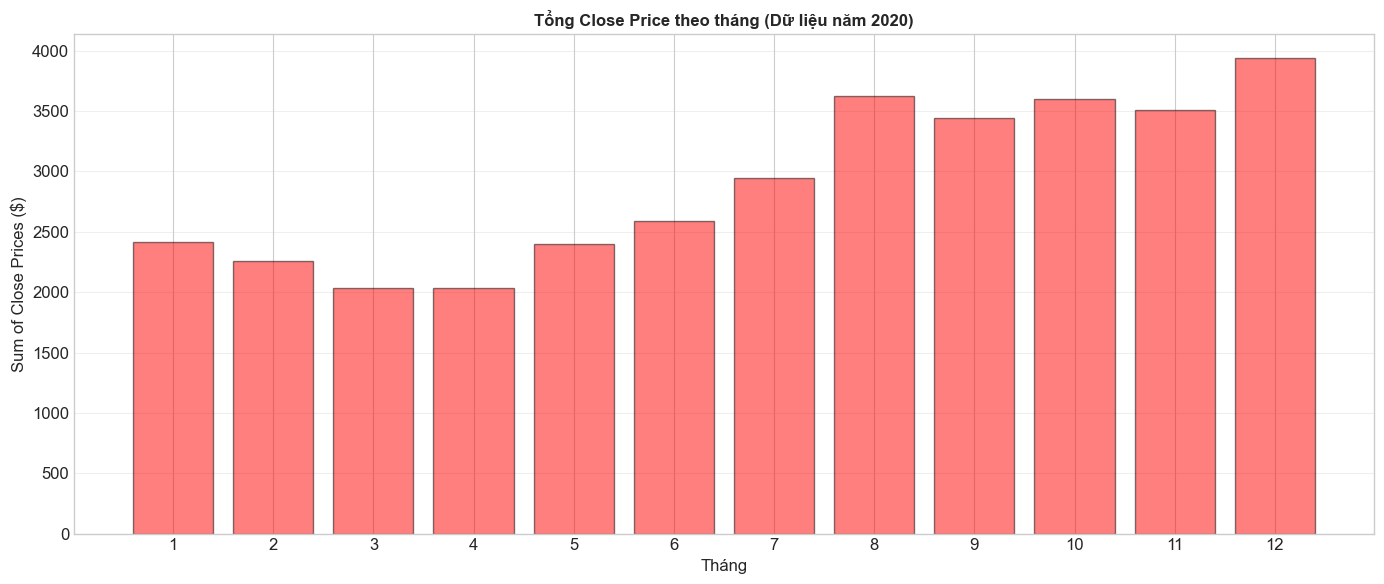

In [509]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_agg.index.month, df_agg['sum'].values, color='red', alpha=0.5, edgecolor='black')
ax.set_title('Tổng Close Price theo tháng (Dữ liệu năm 2020)', 
                   fontweight='bold', fontsize=12)
ax.set_xlabel('Tháng')
ax.set_ylabel('Sum of Close Prices ($)')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Tuy đây là bar chart nhưng hàm sum vẫn phần nào thể hiện được xu hướng của dữ liệu theo thời gian.
- Có một yếu tố khác cần cân nhắc khi sử dụng hàm sum đó là dữ liệu còn phụ thuộc vào số ngày trong tháng. Vì vậy, xu hướng mà ta nhìn được từ biểu đồ phần nào bị nhiễu bởi thông tin này.

Vì vậy, theo quan sát của em hàm sum không phù hợp để phân tích những dữ liệu cần quan sát xu hướng, có thể dùng cho những dữ liệu dạng mật độ (ví dụ trong Dataset này là Volume).

---
## e) Lag Features

#### **Yêu cầu đề bài**
- Create lag features (t − 1, t − 2, ..., t − n). 
- Create rolling window statistics (moving average, rolling standard deviation).
- Create difference features. 
- Discuss autocorrelation and the rationale for choosing appropriate lag values.

#### **Phương hướng tiếp cận**
- Do lag features, rolling window statistics, difference features phục vụ trực tiếp cho ML và hướng đến khi có target cụ thể. Nên em sẽ phân tích các thuộc tính hiện tại để tìm ra target giả sử và tiến hành các bước Tiền xử lý này.

##### 1. Tìm hiểu khái niệm

Tiếp cận Lag features em làm quen 2 khái niệm mới: autocorrelation (mức độ tương quan giữa một biến với chính nó trong quá khứ) và stationary (độ dừng của 1 chuỗi dữ liệu).  

**Autocorrelation**  
* Autocorrelation cao cho thấy giá trị hiện tại phụ thuộc mạnh vào các giá trị trong quá khứ. Nghĩa là lag feature có thể cung cấp thông tin hữu ích cho mô hình. 
* Ngược lại, nếu autocorrelation thấp, các giá trị quá khứ ít đóng góp vào khả năng dự báo hiện tại. Do đó, phân tích autocorrelation giúp xác định số lượng lag phù hợp.

**Stationary**  
* Stationarity phản ánh mức độ ổn định của chuỗi theo thời gian.
* Trong trường hợp chuỗi không stationary, mình sẽ cần cách kĩ thuật transform thêm để đưa dữ liệu về khoảng ổn định trước khi modeling (em hiểu như bước normalize của dữ liệu tabular). Ở đây, bước transform đó là Differences feature extracting.


Trong các thuộc tính của dataset, các biến như Open, High, Low, Volume, Close và Adjusted Close đều có thể được lựa chọn làm target. Em muốn chọn 1 target cần áp dụng toàn bộ technique (autocorrelation cao, non-stationary).

In [510]:
df_caue = df_cauc.copy()

#### 2. Tiến hành triển khai

**Kiểm tra Autocorrelation và Stationary**

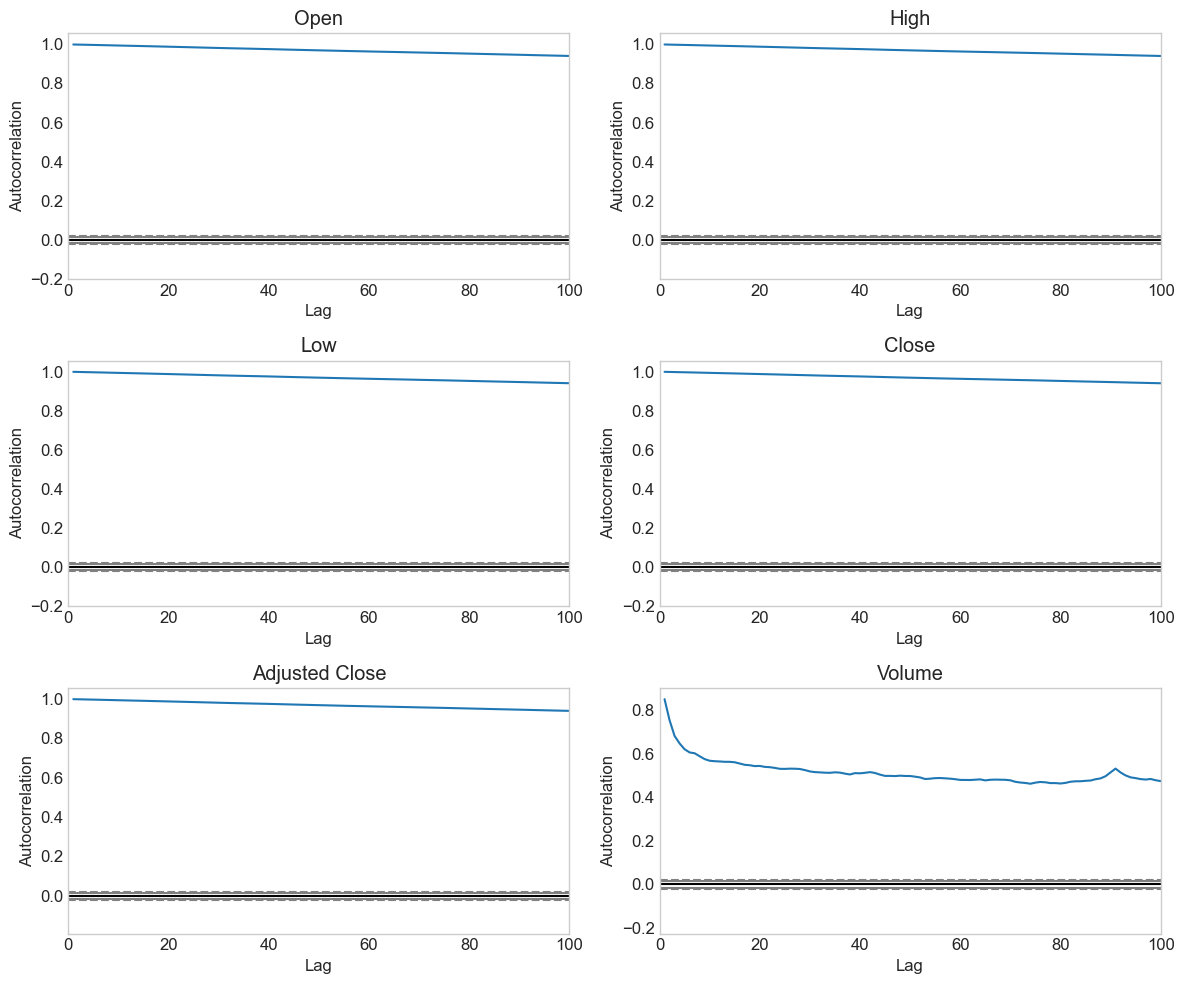

In [511]:
features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    pd.plotting.autocorrelation_plot(
        df_caue[feature].dropna(),
        ax=axes[i]
    )
    axes[i].set_xlim(0, 100)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

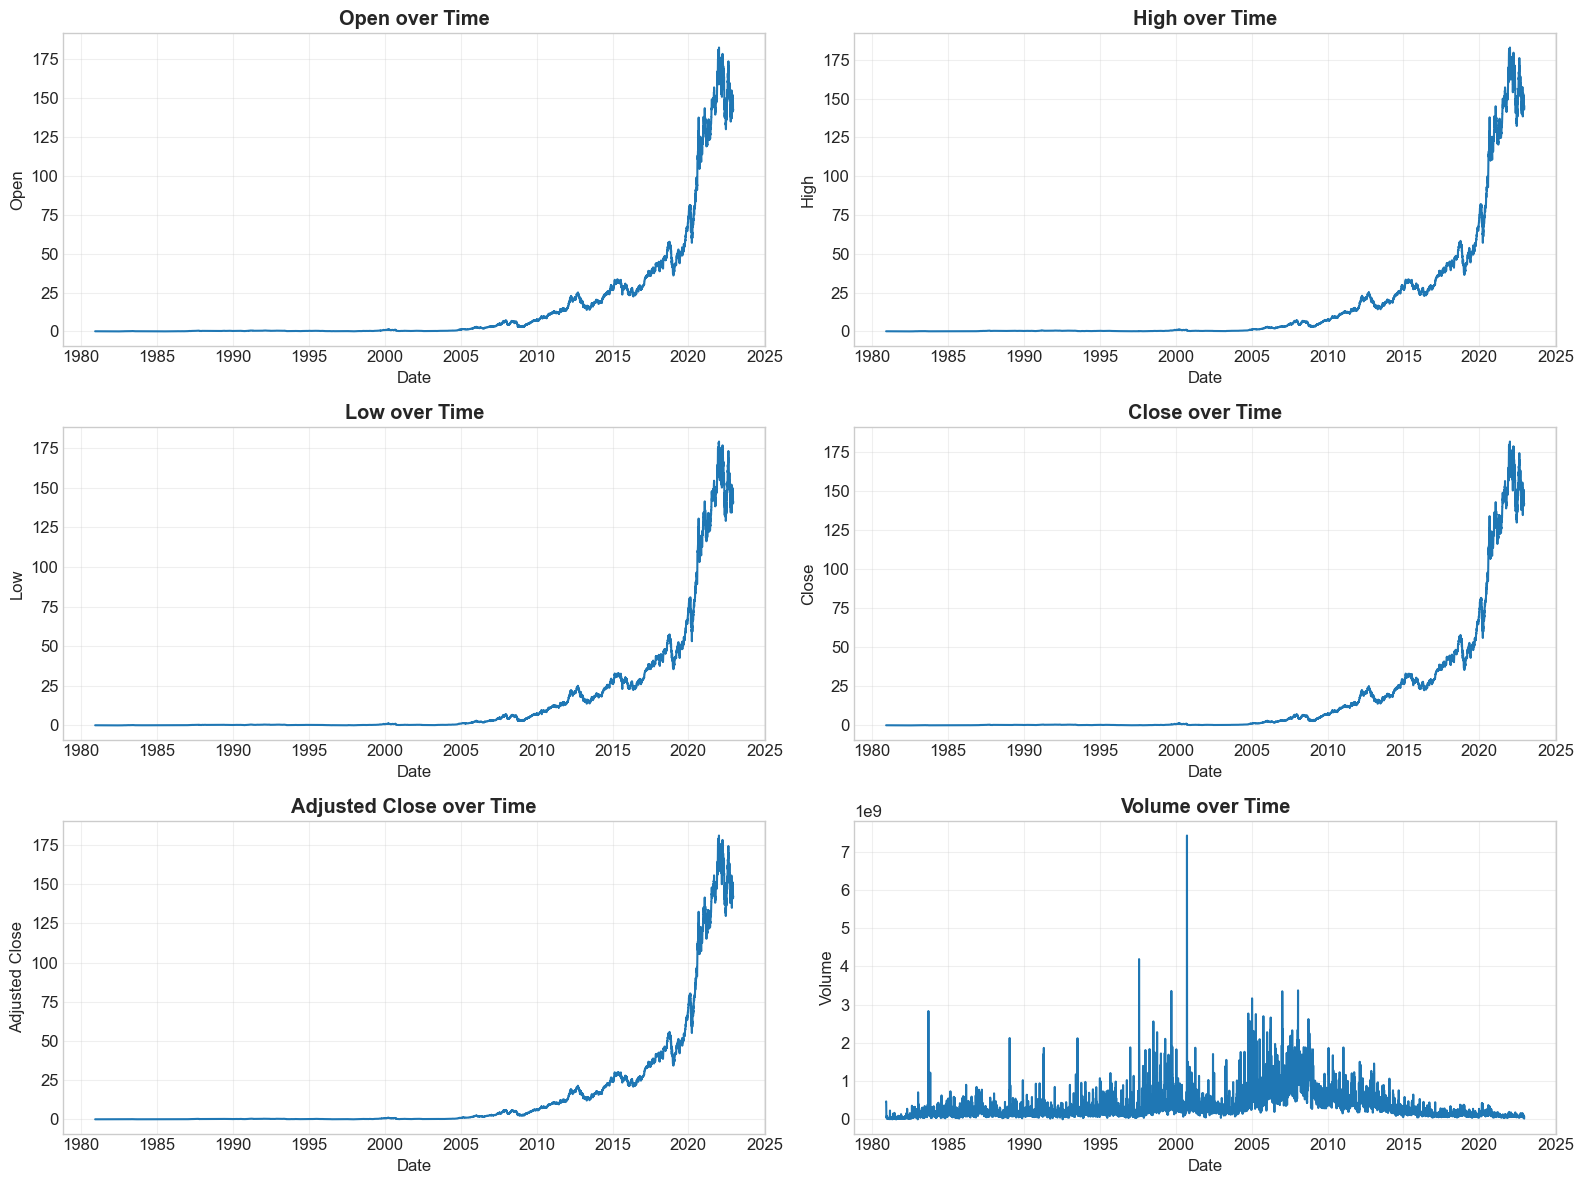

In [512]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].plot(df_caue.index, df_caue[feature])
    axes[i].set_title(f'{feature} over Time', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(feature)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Nhận xét Autocorrelation:

- Hầu hết các đặc trưng (Open, High, Low, Close, Adj Close) có hệ số tự tương quan bắt đầu ở mức rất cao ($r \approx 1.0$) và giảm rất chậm theo thời gian.
- Riêng biểu đồ Volume có sự sụt giảm autocorrelation nhanh hơn nhiều so với các biến giá, cho thấy Volume có tính biến động cao và ít mang tính xu hướng dài hạn hơn.

Nhận xét Stationary:
- Ngoại trừ Volume, các giá trị còn lại do là giá nên có xu hướng tăng trưởng mạnh mẽ (đặc biệt là khoảng sau năm 2010).

Nhìn vào biểu đồ, 5 biến giá (Open, High, Low, Close, Adjusted Close) có hình dạng gần như trùng khớp hoàn toàn. Do đó, dự báo một biến có thể coi là đại diện cho xu hướng chung của các biến còn lại.
Về mặt ý nghĩa, Close phản ánh giá trị cuối cùng mà thị trường chấp nhận trong một ngày giao dịch, là cột mốc quan trọng nên em sẽ chọn dùng Close để khảo sát cho phần này

**Difference features**

Em chọn khảo sát 3 differences feature:
- Giá trị hiện tại trừ giá trị của ngày trước đó
- Giá trị hiện tại trừ giá trị của 7 ngày trước đó (để mô phỏng 1 tuần, đáng ra nên là 5 ngày làm việc nhưng ở đây dữ liệu em đã thực hiện fill rồi)
- Phần trăm thay đổi so với ngày trước đó (có thể hiểu là tỷ suất sinh lời)

In [513]:
df_caue['Close_diff_1'] = df_caue['Close'].diff(1)
df_caue['Close_diff_7'] = df_caue['Close'].diff(7)  
df_caue['Close_pct_change'] = df_caue['Close'].pct_change() * 100 
print("Difference features:")
df_caue[['Close', 'Close_diff_1', 'Close_diff_7', 'Close_pct_change']].tail(10)

Difference features:


,Close,Close_diff_1,Close_diff_7,Close_pct_change
2022-12-03,147.809998,0.000000,-0.300003,0.000000
2022-12-04,147.809998,0.000000,-0.300003,0.000000
2022-12-05,146.630005,-1.179993,2.410004,-0.798317
2022-12-06,142.910004,-3.720001,1.740005,-2.536999
2022-12-07,140.940002,-1.970001,-7.089996,-1.378491
2022-12-08,142.649994,1.709991,-5.660004,1.213276
2022-12-09,142.160004,-0.489990,-5.649994,-0.343491
2022-12-10,142.160004,0.000000,-5.649994,0.000000
2022-12-11,142.160004,0.000000,-5.649994,0.000000
2022-12-12,142.240005,0.080002,-4.389999,0.056276


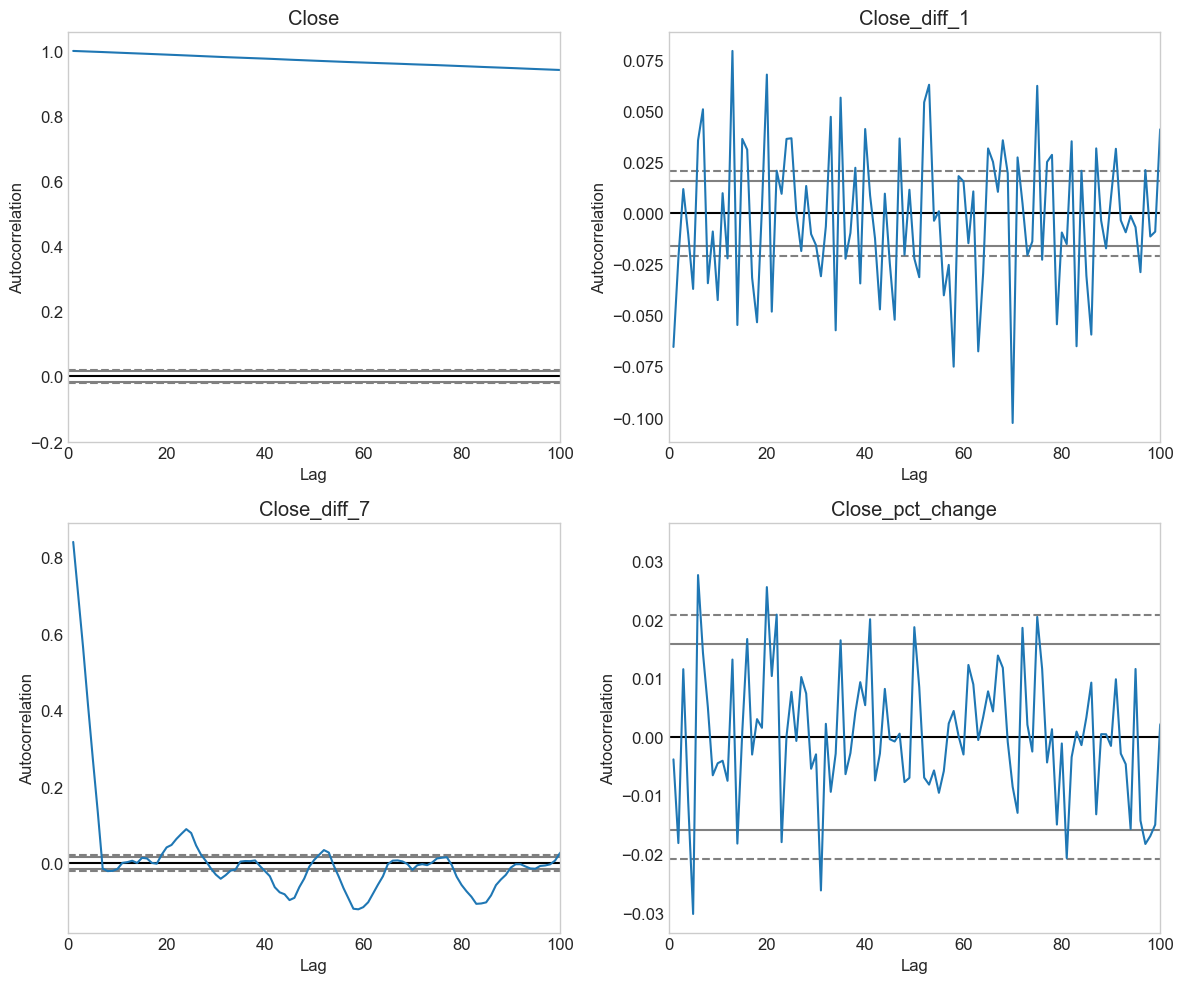

In [514]:
diff_close = ['Close', 'Close_diff_1', 'Close_diff_7', 'Close_pct_change']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(diff_close):
    pd.plotting.autocorrelation_plot(
        df_caue[feature].dropna(),
        ax=axes[i]
    )
    axes[i].set_xlim(0, 100)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Ở đây em đón nhận một bài toán mới. Ban đầu mục tiêu của em là tìm 1 target có autocorrelation tương đối (autocorrelation cao thì lag feature mới chứa nhiều thông tin). Tuy nhiên sau khi tạo difference feature và khảo sát thì autocorrelation của các feature này không quá cao.
- Ngoại trừ feature `Close_diff_7`, bây giờ em sẽ tiến hành quan sát kĩ hơn feature này

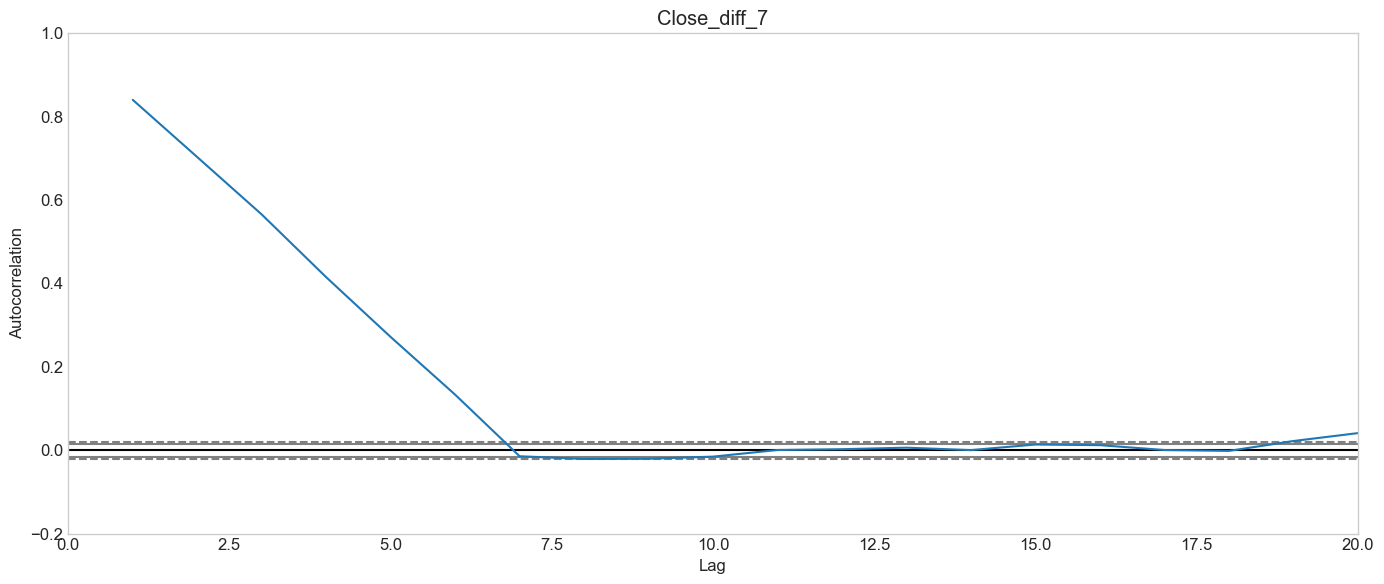

In [515]:
pd.plotting.autocorrelation_plot(df_caue['Close_diff_7'].dropna())
plt.title('Close_diff_7')
plt.xlim(0, 20)
plt.ylim(-0.2, 1)

plt.tight_layout()
plt.show()

#### Nhận xét:
- Nhìn vào biểu đồ lần này, em thấy được giá trị autocorrelation giảm dần tương ứng với lag = 0 -> lag = 7. Hiện tượng này giống quan hệ về mặt toán học hơn là nó thực sự có mối liên hệ ở dạng dữ liệu.


Cụ thể, `Close_diff_7` thực chất là tổng của 7 nhiễu liên tiếp. Do các quan sát liền kề có phần dữ liệu chồng lấp, chúng sẽ tự nhiên tương quan với nhau ở các lag nhỏ. Khi hết phần chồng lấp (tại lag 7), tự tương quan sẽ biến mất.  
Vì vậy, autocorrelation quan sát được là hệ quả cấu trúc của phép biến đổi, không phải tín hiệu kinh tế thực sự.

Sau quá trình phân tích, em nhận ra hiện tại không có lựa chọn nào là hoàn hảo với định hướng phân tích ban đầu của em. Vì vậy, để đảm bảo lag features vẫn có ý nghĩa, em sẽ chọn `Close_pct_change` để phân tích.

**Tạo lag features**

Từ biểu đồ Autocorrelation của `Close_pct_change`, em nhận thấy không có lag nào nổi bật để phân tích, thậm chí dữ liệu chỉ dao động quanh 0 với biên độ (-0.03, 0.03). Vì vậy em sẽ lựa chọn một số lag ngắn để quan sát mối quan hệ ngắn hạn của giá trị này.

Đó là lý do em lựa chọn khảo sát lag 1, 2, 3

In [516]:
for lag in [1, 2, 3]:
    df_caue[f'Close_lag_{lag}'] = df_caue['Close_pct_change'].shift(lag)

print("Lag features:")
df_caue[['Close', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3']].tail(10)

Lag features:


,Close,Close_lag_1,Close_lag_2,Close_lag_3
2022-12-03,147.809998,-0.337132,0.189150,4.859390
2022-12-04,147.809998,0.000000,-0.337132,0.189150
2022-12-05,146.630005,0.000000,0.000000,-0.337132
2022-12-06,142.910004,-0.798317,0.000000,0.000000
2022-12-07,140.940002,-2.536999,-0.798317,0.000000
2022-12-08,142.649994,-1.378491,-2.536999,-0.798317
2022-12-09,142.160004,1.213276,-1.378491,-2.536999
2022-12-10,142.160004,-0.343491,1.213276,-1.378491
2022-12-11,142.160004,0.000000,-0.343491,1.213276
2022-12-12,142.240005,0.000000,0.000000,-0.343491


**Correlation matrix cho lag features**

In [517]:
lag_cols = ['Close_pct_change', 'Close_lag_1', 'Close_lag_2', 
            'Close_lag_3']

corr_matrix = df_caue[lag_cols].corr()

corr_matrix

,Close_pct_change,Close_lag_1,Close_lag_2,Close_lag_3
Close_pct_change,1.000000,-0.003839,-0.018118,0.011549
Close_lag_1,-0.003839,1.000000,-0.003839,-0.018118
Close_lag_2,-0.018118,-0.003839,1.000000,-0.003839
Close_lag_3,0.011549,-0.018118,-0.003839,1.000000


Giống như nhận định ban đầu của em, correlation matrix cho thấy giữa các lag không có mối quan hệ tuyến tính. Tuy vậy, không thể khẳng định giữa các feature này và `Close_pct_change` không tồn tại mối quan hệ nào.

Có thể có tồn tại những mối quan hệ phức tạp hơn giữa các feature này. Về phần feature Close, em đã thử khảo sát lag feature và kết quả cho ra dữ liệu bị đa cộng tuyến do tương quan quá mạnh (nhưng notebook quá dài nên em không thể hiện kết quả đó ở đây).

**Rolling Window Statistics**

Em sẽ chọn khai thác các mốc thời gian:
- 7 ngày: để khai thác những mối quan hệ ngắn hạn. Ở mức này, em có thể khai thác những mối quan hệ tức thời nhưng đỡ nhiễu hơn giá trị gốc.
- 30 ngày: để khai thác chu kỳ tháng. Ở mức này em chọn để khai thác trọng tâm (dựa vào phần resampling em nhận thấy xu hướng monthly rất ổn định, rõ ràng)
- 60 ngày: để khai thác những chuyển động dài hơn của thị trường

*Tính các rolling statistics (dùng mốc 30 ngày)*

In [518]:
# chừa mean tính riêng ở dưới
df_caue['Std_30'] = df_caue['Close'].rolling(30).std()
df_caue['Min_30'] = df_caue['Close'].rolling(30).min()
df_caue['Max_30'] = df_caue['Close'].rolling(30).max()

*Tính mean rolling statistic (moving average)*

###### Do mean khá ổn định nên em sẽ chọn để khảo sát xu hướng thời gian

In [519]:
df_caue['MA_7'] = df_caue['Close'].rolling(7).mean()
df_caue['MA_30'] = df_caue['Close'].rolling(30).mean()
df_caue['MA_60'] = df_caue['Close'].rolling(60).mean()

In [520]:
print("Các statistic đã tạo:")
df_caue[['Close', 'MA_7', 'MA_30', 'Std_30', 'Min_30', 'Max_30']].tail(10)

Các statistic đã tạo:


,Close,MA_7,MA_30,Std_30,Min_30,Max_30
2022-12-03,147.809998,146.494284,146.603665,4.862455,134.869995,151.289993
2022-12-04,147.809998,146.451427,146.917998,4.610793,134.869995,151.289993
2022-12-05,146.630005,146.795713,147.192998,4.320919,134.869995,151.289993
2022-12-06,142.910004,147.044285,147.343998,4.074441,134.869995,151.289993
2022-12-07,140.940002,146.031429,147.411332,3.945064,134.869995,151.289993
2022-12-08,142.649994,145.222857,147.516331,3.765052,134.869995,151.289993
2022-12-09,142.160004,144.415715,147.759332,3.096615,140.940002,151.289993
2022-12-10,142.160004,143.608573,147.602332,3.258431,140.940002,151.289993
2022-12-11,142.160004,142.801431,147.350999,3.379592,140.940002,151.289993
2022-12-12,142.240005,142.174288,147.102333,3.473927,140.940002,151.289993


**Biểu đồ các đường RS dùng mốc 30 ngày (dữ liệu từ năm 2020 trở đi)**

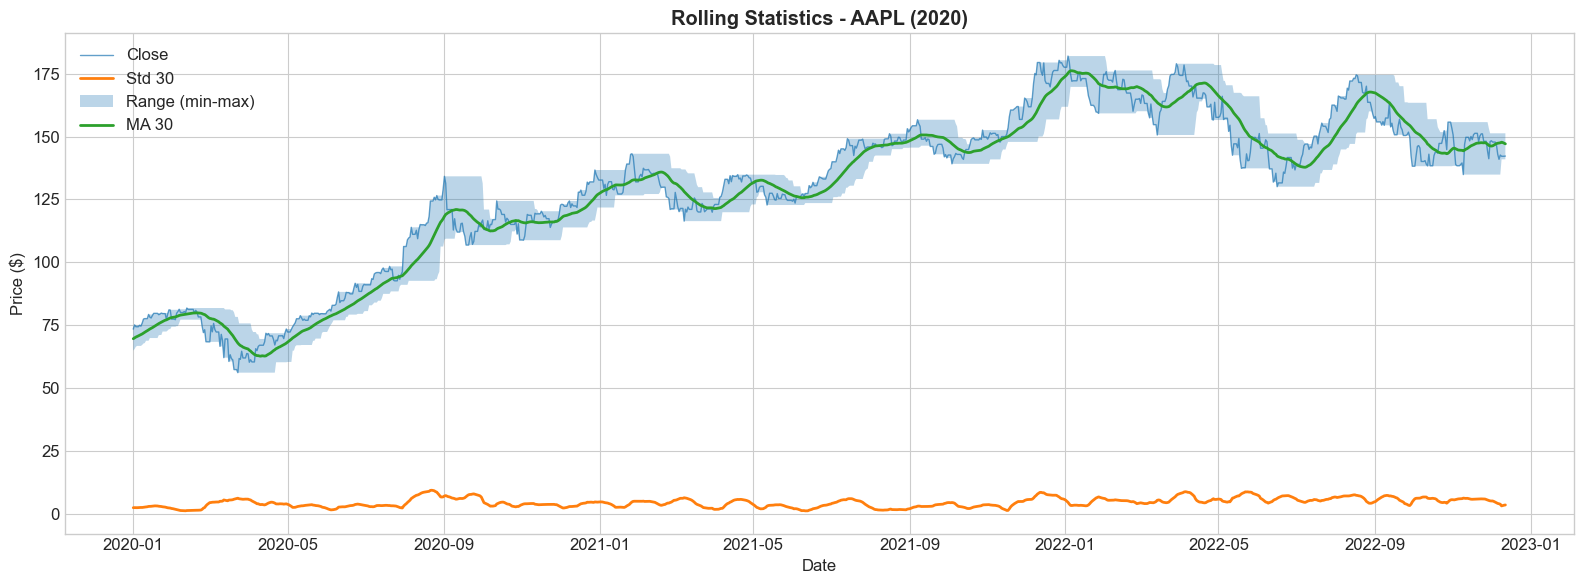

In [524]:
recent_rs = df_caue.loc['2020':]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent_rs.index, recent_rs['Close'], label='Close', alpha=0.7, linewidth=1)
ax.plot(recent_rs.index, recent_rs['Std_30'], label='Std 30', linewidth=2)
ax.fill_between(recent_rs.index, recent_rs['Min_30'], recent_rs['Max_30'], alpha=0.3, label='Range (min-max)')
ax.plot(recent_rs.index, recent_rs['MA_30'], label='MA 30', linewidth=2)

ax.set_title('Rolling Statistics - AAPL (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()



**Nhận xét:**
- Đường MA_30 đã thành công trong việc bắt trọn xu hướng của Close. Tuy nhiên do là trung bình cộng của 30 ngày nên không thể hiện được sự dao động, biên độ thay đổi của dữ liệu. Vì vậy, đường mean nên được dùng khi ta muốn thể hiện xu hướng theo thời gian của dữ liệu một cách tổng quát, không cần capture toàn bộ biến động.
- Nếu cần capture toàn bộ biến động thì range min và max đã làm tốt điều này. Ta có thể dùng 2 giá trị này khi cần quan sát sự biến động của thị trường (thông qua khoảng cách giữa 2 đường).
- Đường Std_30 cho thấy sự biến động của dữ liệu. Nếu đường này dốc lên tức là giá của cổ phiếu đang thay đổi. 

**Biểu đồ các đường MA (dữ liệu từ năm 2020 trở đi)**

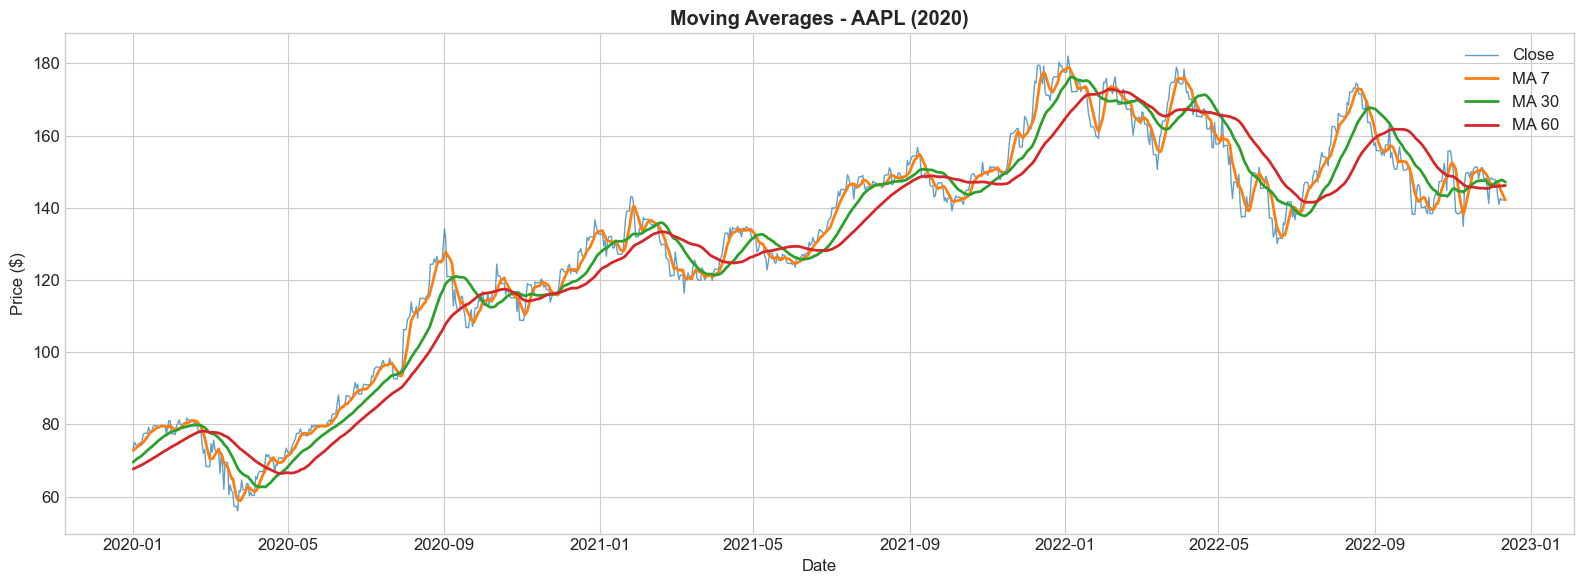

In [523]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(recent_rs.index, recent_rs['Close'], label='Close', alpha=0.7, linewidth=1)
ax.plot(recent_rs.index, recent_rs['MA_7'], label='MA 7', linewidth=2)
ax.plot(recent_rs.index, recent_rs['MA_30'], label='MA 30', linewidth=2)
ax.plot(recent_rs.index, recent_rs['MA_60'], label='MA 60', linewidth=2)

ax.set_title('Moving Averages - AAPL (2020)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- 3 đường thể hiện đúng với lựa chọn ban đầu của em. Điều đó cho thấy ta đã thành công tạo rolling window statistic cho dữ liệu (vì đây là lab pre-processing nên em không nhận xét nhiều về xu hướng, insight từ dữ liệu, vì vậy nên ở đây em không biết nhận xét gì thêm)